In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import hist

In [2]:
base_dir = Path.cwd().parent.parent.parent
python_dir = base_dir / "build" / "Python"
sys.path.insert(0, str(python_dir))

In [3]:
import acts
import acts.examples
u = acts.UnitConstants

In [4]:
lb_size = 10000
num_lbs = 4

In [5]:
rng = acts.examples.RandomEngine()
gaussian = acts.examples.GaussianVertexGenerator(
    stddev=acts.Vector4(0.01 * u.mm, 0.01 * u.mm, 50 * u.mm, 1 * u.ns),
    mean=acts.Vector4(0, 0, 0, 0),
)
lumi_shift = acts.examples.LumiBlockVertexGenerator(
    blockSize=lb_size,
    stddev=acts.Vector4(0.01 * u.mm, 0.01 * u.mm, 100.0 * u.mm, 0),
)
combined = acts.examples.AdditiveVertexGenerator(
    generators=[
    gaussian,
    lumi_shift
    ]
)

# Should produce varying positions within a block (gaussian component)
positions = np.array([np.array(combined(rng, evt)) for evt in range(num_lbs * lb_size)])

In [6]:
def plot_positions(positions):
    fig, ax = plt.subplots(figsize=(7, 7))

    for lb in range(num_lbs):
        ax.scatter(positions[lb * lb_size:(lb + 1) * lb_size, 0], positions[lb * lb_size:(lb + 1) * lb_size, 1], s=1)

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_aspect(1)

    plt.show()

    fig, ax = plt.subplots(figsize=(7, 7))

    for lb in range(num_lbs):
        ax.scatter(positions[lb * lb_size:(lb + 1) * lb_size, 0], positions[lb * lb_size:(lb + 1) * lb_size, 2], s=1)

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [mm]")

    plt.show()

    fig, ax = plt.subplots(figsize=(7, 7))

    for lb in range(num_lbs):
        ax.scatter(positions[lb * lb_size:(lb + 1) * lb_size, 1], positions[lb * lb_size:(lb + 1) * lb_size, 2], s=1)

    ax.set_xlabel("y [mm]")
    ax.set_ylabel("z [mm]")

    plt.show()

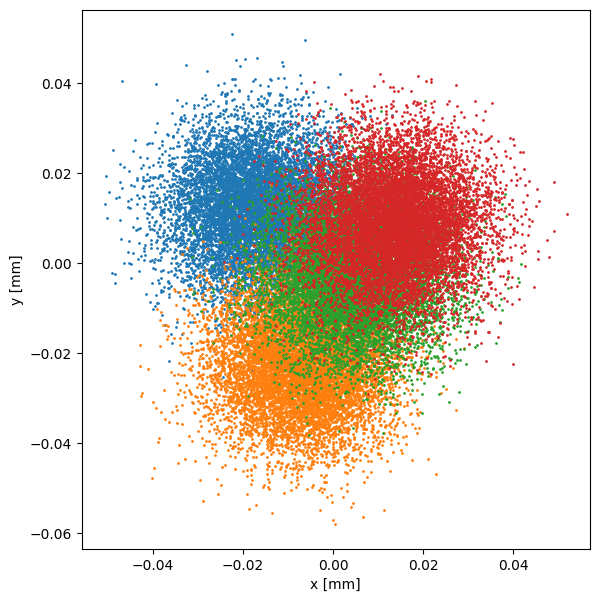

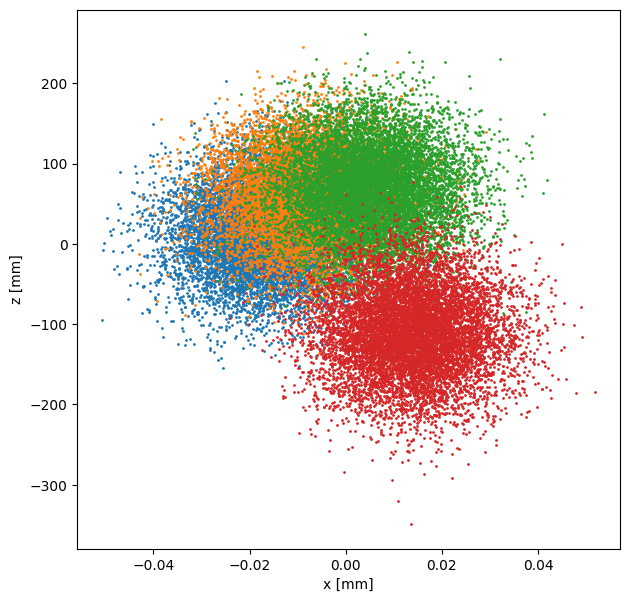

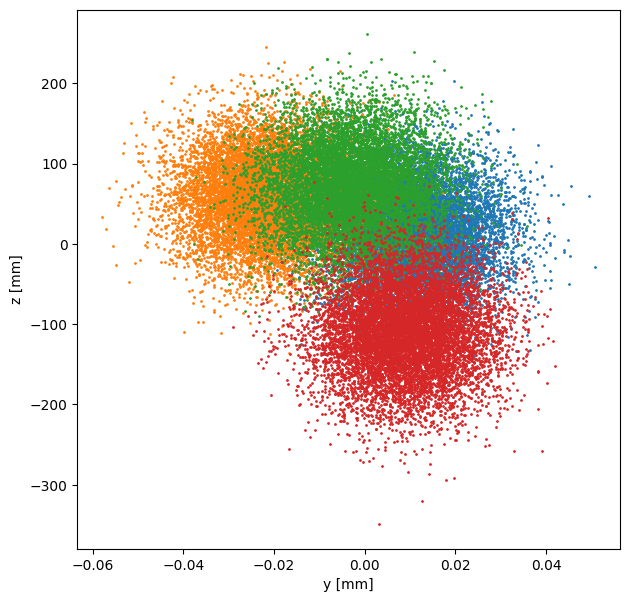

In [7]:
plot_positions(positions)

In [8]:
rng = acts.examples.RandomEngine()
gaussian = acts.examples.GaussianVertexGenerator(
    stddev=acts.Vector4(0.01 * u.mm, 0.01 * u.mm, 50 * u.mm, 1 * u.ns),
    mean=acts.Vector4(0, 0, 0, 0),
)
tilted_gaussian = acts.examples.LumiBlockRotationVertexGenerator(
    base=gaussian,
    blockSize=lb_size,
    xAngleStddev=0.001,
    yAngleStddev=0.001,
)
lumi_shift = acts.examples.LumiBlockVertexGenerator(
    blockSize=lb_size,
    stddev=acts.Vector4(0.1 * u.mm, 0.1 * u.mm, 100.0 * u.mm, 0),
)
combined = acts.examples.AdditiveVertexGenerator(
    generators=[
        tilted_gaussian,
        lumi_shift,
    ]
)

# Should produce varying positions within a block (gaussian component)
positions = np.array([np.array(combined(rng, evt)) for evt in range(num_lbs * lb_size)])

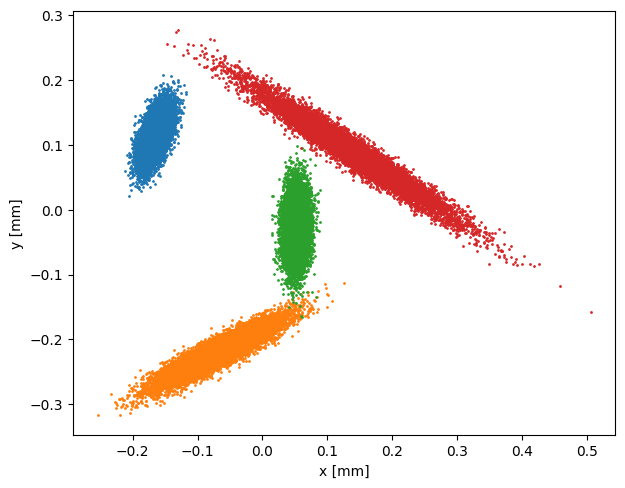

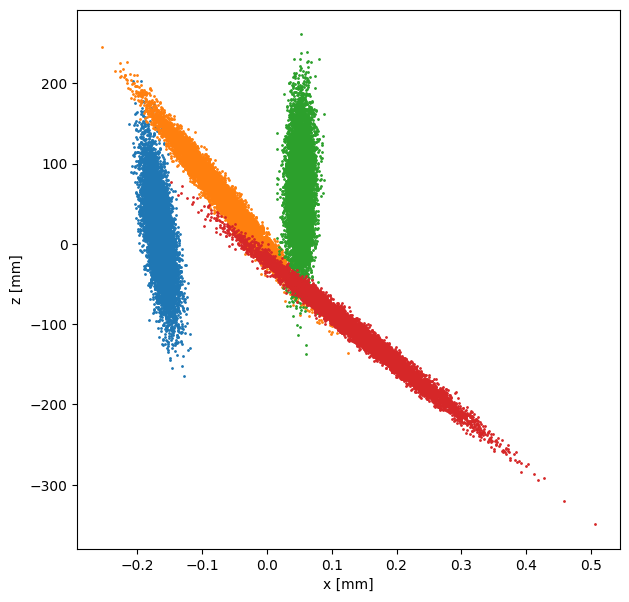

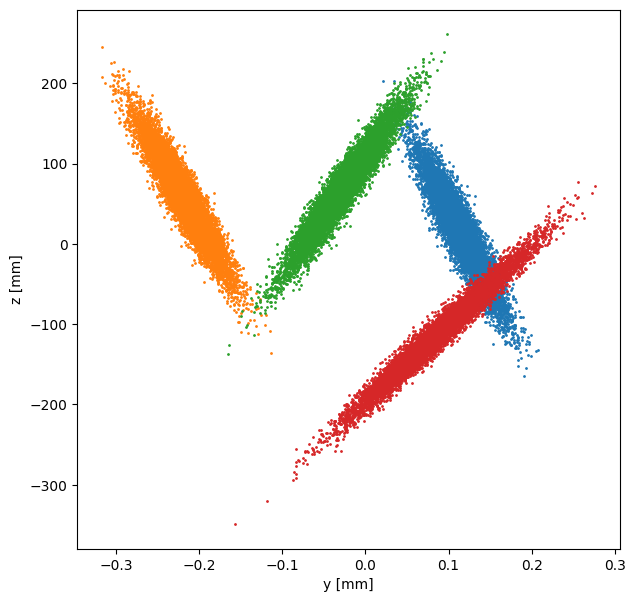

In [9]:
plot_positions(positions)